<a href="https://colab.research.google.com/github/NAMU578/INFSUB/blob/main/notebooks/2_%EB%84%98%ED%8C%8C%EC%9D%B4_%EC%8B%AC%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 파이썬 넘파이(NumPy) 심화

[넘파이 공식 사이트](https://numpy.org/doc/stable/index.html)

## (1) 복습

### 1)Numpy 특징

* Numerical Python의 약자
* 고성능 과학 계산용 패키지로 강력한 N차원(N dimension) 배열 객체
* 정교한 브로드캐스팅(broadcasting) 기능
* 파이썬의 자료형 list와 비슷하지만, **더 빠르고 메모리를 효율적으로 관리**
* **반복문 없이** 데이터 배열에 대한 처리를 지원하여 빠르고 편리
* 데이터 과학 도구에 대한 생태계의 핵심을 이루고 있음

In [ ]:
# numpy 모듈을 가져와 np로 짧게 표현하여 사용할 수 있도록 해 보자
# (단, numpy 모듈은 설치되어 있다고 가정함.)..
import numpy as np

In [ ]:
# 구글 drive에 있는 데이터 연결하기 전 드라이브 연동시킬 때
# from google.colab import drive
# drive.mount('/content/drive')

### 2)간단하게 넘파이 배열 만들고 활용하기

In [ ]:
# arange()로 1에서 6까지 값을 가진 배열을 만들고 모양을 2행 3열로 재구성
m = np.arange(1,7).reshape(2,3)
m

array([[1, 2, 3],
       [4, 5, 6]])

In [ ]:
type(m)

numpy.ndarray

In [ ]:
for i, a in enumerate(m):
  print(i, a)

0 [1 2 3]
1 [4 5 6]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print("행 렬 값")
for i, a in enumerate(m):
  for j, b in enumerate(a):
    print(f" {i}  {j}  {b}")

행 렬 값
 0  0  1
 0  1  2
 0  2  3
 1  0  4
 1  1  5
 1  2  6


## (2) numpy를 왜 배울까?

**왜 넘파이를 배워야 할까? 예시1**<br>
인공지능 연구에서 이미지 자료를 하나 가져와서 분석을 한다고 가정해 보자.<br>
이미지 파일을 읽어와서 메모리에 저장할 때 어떻게 저장이 될까?<br>
이런 문제에 많이 활용되는 opencv의 경우 읽어온 이미지를 넘파이 배열에 저장하여 처리한다.

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

In [ ]:
#구글 drive에 있는 데이터 연결 시도
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
img1 = cv2.imread('/content/bad_dog.png') # 경로 확인

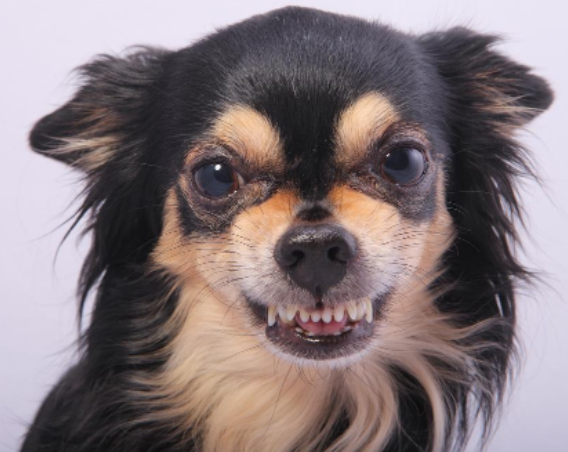

In [ ]:
cv2_imshow(img1)

In [ ]:
type(img1), img1.ndim, img1.shape, img1.size

(numpy.ndarray, 3, (452, 568, 3), 770208)

In [ ]:
print(img1)

[[[241 227 233]
  [241 227 233]
  [241 227 233]
  ...
  [243 229 233]
  [243 229 233]
  [243 229 233]]

 [[241 227 233]
  [241 227 233]
  [241 227 233]
  ...
  [243 229 233]
  [243 229 233]
  [243 229 233]]

 [[241 227 233]
  [241 227 233]
  [241 227 233]
  ...
  [243 229 233]
  [243 229 233]
  [243 229 233]]

 ...

 [[205 183 188]
  [205 183 188]
  [206 184 189]
  ...
  [208 187 190]
  [208 187 190]
  [208 187 190]]

 [[203 181 186]
  [204 182 187]
  [205 183 188]
  ...
  [207 186 189]
  [207 186 189]
  [207 186 189]]

 [[202 180 185]
  [202 180 185]
  [204 182 187]
  ...
  [207 186 189]
  [207 186 189]
  [207 186 189]]]


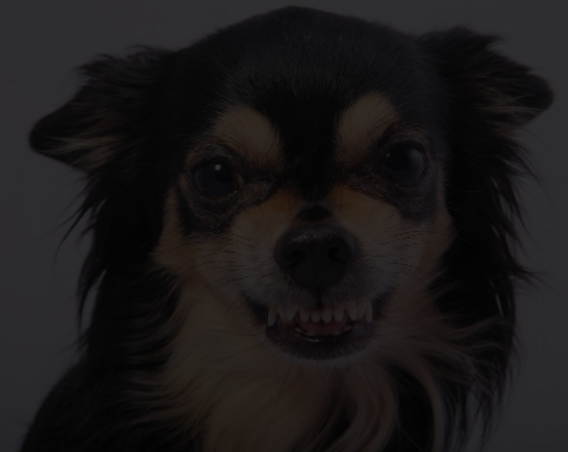

In [ ]:
img2 = img1 * 0.2
# print(img2)
cv2_imshow(img2)

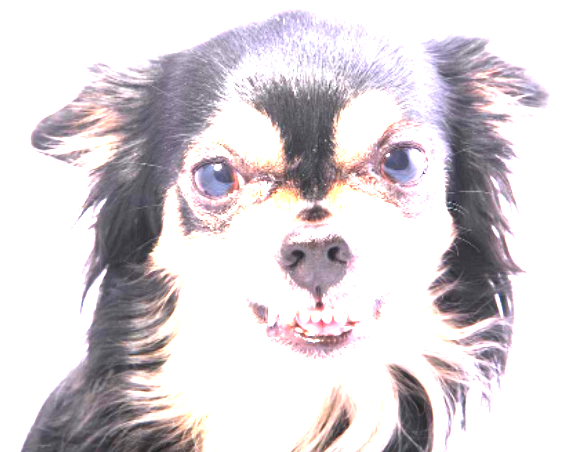

In [ ]:
img3 = img1 * 3.0
cv2_imshow(img3)

**왜 넘파이를 배워야 할까? 예시2**<br>
다음과 같은 방정식의 해를 구할 때도 행렬이 사용된다.<br>
\begin{align*}
    x + y =  25 \\  
    2x + 4y =  64 \\
\end{align*}
<br>
$$ \left(
\begin{matrix}
    1 & 1 \\
    2 & 4 \\
\end{matrix}
\right)
\left(
\begin{matrix}
    x \\
    y \\
\end{matrix}
\right) =
\left(
\begin{matrix}
    25 \\
    64 \\
\end{matrix}
\right)
$$

In [ ]:
from numpy import linalg

A = np.array([[1, 1], [2, 4]])
B = np.array([25, 64])
x = linalg.solve(A, B)
x

array([18.,  7.])

## (3) 다양한 넘파이 배열 생성 방법

### 1)파이썬 리스트를 이용하여 넘파이 배열 만들기

In [ ]:
l = [1,2,3,4]
print(type(l))
a = np.array(l)
a

<class 'list'>


array([1, 2, 3, 4])

In [ ]:
type(a)

numpy.ndarray

#### ① 넘파이 배열의 속성들

* itemsize 속성: 원소 하나의 크기(자료형의 크기, 바이트 단위)

In [ ]:
#a.dtype 이 int64이므로
a.itemsize

8

* size 속성: 원소의 개수

In [ ]:
a.size

4

* strides 속성: 배열의 각 차원에서 다음 요소로 이동하기 위한 메모리 상의 바이트 수.  
단, 배열의 차원에 따라 확장되어 표시(바이트 단위)됨. <br>
- 1차원일 경우: 원소 하나의 크기<br>
- 2차원일 경우: 한 행 전체 크기, 원소 하나 크기
- 3차원일 경우: 한 면 전체 크기, 한행 전체 크기, 원소 하나 크기

In [ ]:
a.strides

(8,)

In [ ]:
# 2차원 배열의 size, strides 속성
b = np.array([[1, 2, 3], [4, 5, 6]])

In [ ]:
b.itemsize, b.size, b.strides

(8, 6, (24, 8))

In [ ]:
# 3차원 배열의 size, strides 속성
c = np.arange(1,25).reshape(4,3,2)

In [ ]:
c.itemsize, c.size, c.strides

(8, 24, (48, 16, 8))

#### ② 잘 이해하고 있는지 테스트해 보자

In [ ]:
na = np.array([[[1,2,3],[4,5,6]]])
na

array([[[1, 2, 3],
        [4, 5, 6]]])

In [ ]:
# 실행하기 전에 ( ) 에 예측한 값을 적어 놓고 실행해 보시오
# (3 8 6                                              )
na.ndim, na.shape, na.itemsize, na.size, na.strides

(3, (1, 2, 3), 8, 6, (48, 24, 8))

#### ③ 넘파이 모듈의 배열 내부구조 확인

* data 속성: 다차원 배열의 데이터를 관리하는 속성. data를 조회하면 메모리에 저장된 주소를 출력해 줌

In [ ]:
l = [1,2,3,4]
a = np.array(l)
a.data

* hex() 메소드: data 속성에 있는 배열의 원소들을 모두 16진수로 변환

In [ ]:
hex(127)

'0x7f'

In [ ]:
# 3차원 배열도 메모리 속에 저장될 때는 1차원 형태로 저장
na = np.arange(1,7).reshape(3,2)
print(na)
na.data.hex()

[[1 2]
 [3 4]
 [5 6]]


'010000000000000002000000000000000300000000000000040000000000000005000000000000000600000000000000'

In [ ]:
nb = np.array([255, 4095, 65535, 1048575])
nb.data.hex()

'ff00000000000000ff0f000000000000ffff000000000000ffff0f0000000000'

### 2)파이썬 튜플을 이용하여 넘파이 배열 만들기

In [ ]:
t = (1,2,3,4)
b = np.array(t)
b

array([1, 2, 3, 4])

In [ ]:
type(b)

numpy.ndarray

### 3)넘파이 배열 생성하는 대표적인 함수
 + arange(): 정수 범위로 배열 생성
 + linspace(): 범위 내에서 균등 간격의 배열 생성
 + logspace(): 범위 내에서 균등간격으로 로그 스케일로 배열 생성

#### ① arange 함수로 생성하기
 + arange(시작, 종료, 간격)
 + **종료값은 포함되지 않음**
 + 시작과 간격은 생략가능함.
 + 시작 생략 시 0, 간격 생략 시 1을 기본값으로 지정

In [ ]:
v1 = np.arange(10)
v1

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
v1.dtype

dtype('int64')

In [ ]:
v2 = np.arange(10.5, 20.5, 0.5)
v2

array([10.5, 11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5,
       16. , 16.5, 17. , 17.5, 18. , 18.5, 19. , 19.5, 20. ])

In [ ]:
v2.dtype

dtype('float64')

In [ ]:
v2.size, v2.itemsize

(20, 8)

In [ ]:
# 벡터(1차원 배열)로 생성한 후 모양을 변형하여 활용함. 3*4*5 == 60
v3 = np.arange(60).reshape(3,4,5)
v3

array([[[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]],

       [[20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34],
        [35, 36, 37, 38, 39]],

       [[40, 41, 42, 43, 44],
        [45, 46, 47, 48, 49],
        [50, 51, 52, 53, 54],
        [55, 56, 57, 58, 59]]])

#### ② linspace 함수로 생성하기
 + linspace(시작, 종료, 개수)
 + **종료값도 포함**해서 배열의 원소 만듦. 만약 종료값을 제외하려면 매개변수 endpoint 사용.
 + 시작과 종료는 생략할 수 없음. **개수를 생략할 경우 50(기본값)** 적용됨.
 + 간격 확인할 수 있는 매개변수: retstep

In [ ]:
data = np.linspace(0, 10, 10)
data

array([ 0.        ,  1.11111111,  2.22222222,  3.33333333,  4.44444444,
        5.55555556,  6.66666667,  7.77777778,  8.88888889, 10.        ])

In [ ]:
lin1 = np.linspace(1, 10) # 개수 생략이므로 기본 50개 생성
lin1

array([ 1.        ,  1.18367347,  1.36734694,  1.55102041,  1.73469388,
        1.91836735,  2.10204082,  2.28571429,  2.46938776,  2.65306122,
        2.83673469,  3.02040816,  3.20408163,  3.3877551 ,  3.57142857,
        3.75510204,  3.93877551,  4.12244898,  4.30612245,  4.48979592,
        4.67346939,  4.85714286,  5.04081633,  5.2244898 ,  5.40816327,
        5.59183673,  5.7755102 ,  5.95918367,  6.14285714,  6.32653061,
        6.51020408,  6.69387755,  6.87755102,  7.06122449,  7.24489796,
        7.42857143,  7.6122449 ,  7.79591837,  7.97959184,  8.16326531,
        8.34693878,  8.53061224,  8.71428571,  8.89795918,  9.08163265,
        9.26530612,  9.44897959,  9.63265306,  9.81632653, 10.        ])

In [ ]:
lin2 = np.linspace(1,2 ,10, retstep=True) # 간격 표시
lin2

(array([1.        , 1.11111111, 1.22222222, 1.33333333, 1.44444444,
        1.55555556, 1.66666667, 1.77777778, 1.88888889, 2.        ]),
 np.float64(0.1111111111111111))

In [ ]:
lin3 = np.linspace(1, 10, 10, endpoint=False, retstep=True) # 종료 값 제외
lin3

(array([1. , 1.9, 2.8, 3.7, 4.6, 5.5, 6.4, 7.3, 8.2, 9.1]), np.float64(0.9))

#### ③ logspace 함수로 생성하기
 + 수학의 로그를 이용하여 배열의 원소 생성. 여기서 로그의 밑은 10임.
 + logspace(시작, 종료, 개수)
 + 종료값 포함

In [ ]:
# numpy의 logspace() 함수를 사용하여 10^1부터 10^3까지 10개의 로그 스페이스 값을 생성
data = np.logspace(1, 3, 10)
data

array([  10.        ,   16.68100537,   27.82559402,   46.41588834,
         77.42636827,  129.1549665 ,  215.443469  ,  359.38136638,
        599.48425032, 1000.        ])

In [ ]:
logsp1 = np.logspace(0, 2, 4)
logsp1

array([  1.        ,   4.64158883,  21.5443469 , 100.        ])

In [ ]:
# logspace를 linspace를 이용해 검산해 볼까?

lin4 = np.linspace(0, 2, 4)
lin4

array([0.        , 0.66666667, 1.33333333, 2.        ])

In [ ]:
# 밑이 10인 로그값이라고 할 때 log X 에서 X 부분 확인해 보자.
# 밑이 10일 때
# log(0) -> 1, log(0.66666667) -> 4.64158883 ,  log(1.33333333) ==> 21.544346900318832, log(2) -> 100

for i in lin4:
  print(np.power(10, i), end="    ")

1.0    4.641588833612778    21.544346900318832    100.0    



---



## (4) Numpy 배열의 차원 개념

* 0차원 : 스칼라(scalar, (of a quantity) having only magnitude, not direction.)

In [ ]:
x0 = np.array(1)
x0

array(1)

* 1차원 : 벡터(vector)

In [ ]:
x1 = np.arange(10)
x1

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

* 2차원 : 행렬(matrix)  
※ 2차원을 보통 행렬이라 부른다는 의미.  
※ shape(모양)이 2차원일 때 명칭이 행렬임!  
※ 진짜 행렬(matrix)은 넘파이배열과 좀 차이가 남! 아래에 추가 자료 있으니 참고

In [ ]:
x2 = np.arange(1,7).reshape(2,3)
x2

array([[1, 2, 3],
       [4, 5, 6]])

* 3차원 : 텐서(Tensor)

In [ ]:
x3 = np.arange(1,9).reshape(2,2,2)
x3

array([[[1, 2],
        [3, 4]],

       [[5, 6],
        [7, 8]]])

* 각 narray들의 정보를 출력해 보자.

In [ ]:
x=x1      #x0, x1, x2, x3를 순서대로 넣어서 출력해 보자.
print(f"x = {x}")
print(f"x shape: {x.shape}")
print(f"x dimension: {x.ndim}")
print(f"x strides: {x.strides}") # strides 배운 후 실습해 보자.

x = [0 1 2 3 4 5 6 7 8 9]
x shape: (10,)
x dimension: 1
x strides: (8,)


### 1)두 클래스(ndarray, matrix) 비교

* 두 클래스의 base 비교

In [ ]:
np.ndarray.__bases__

(object,)

In [ ]:
np.matrix.__bases__

(numpy.ndarray,)

* 차원: ndarray는 다양한 차원 가능, matrix는 2차원만 가능

In [ ]:
l = np.arange(1, 9)
print(l)
l.shape

[1 2 3 4 5 6 7 8]


(8,)

In [ ]:
m = np.asmatrix(l)
print(m)
m.shape

[[1 2 3 4 5 6 7 8]]


(1, 8)

In [ ]:
l3 = l.reshape(2,2,2)
l3

array([[[1, 2],
        [3, 4]],

       [[5, 6],
        [7, 8]]])

In [ ]:
m3 = m.reshape(2,2,2)
m3

ValueError: shape too large to be a matrix.

* 행렬곱 비교
 + ndarray의 경우 * 연산은 같은 위치의 원소 간 단순 곱셈
 + matrix의 경우 * 연산은 행렬곱 연산
 + 행렬의 행렬곱연산의 예
$$ \left[
\begin{matrix}
    1 & 2 \\
    3 & 4 \\
\end{matrix}
\right] *
\left[
\begin{matrix}
    1 & 2 \\
    3 & 4 \\
\end{matrix}
\right] =
\left[
\begin{matrix}
    1*1+2*3 & 1*2+2*4 \\
    3*1+4*3 & 3*2+4*4 \\
\end{matrix}
\right]
$$

In [ ]:
n = np.arange(1, 5).reshape(2,2)
print(n)
type(n)

[[1 2]
 [3 4]]


numpy.ndarray

In [ ]:
m = np.asmatrix(n)
print(m)
type(m)

[[1 2]
 [3 4]]


numpy.matrix

In [ ]:
# ndarray의 경우 * 연산은 같은 위치의 원소 간 단순 곱셈
n*n

array([[ 1,  4],
       [ 9, 16]])

In [ ]:
# matrix의 경우 * 연산은 행렬곱 연산
# 그러므로 행렬곱 연산이 가능하려면, 첫번째 행렬의 열과 두번째 행렬의 행이 같아야 함!
m*m

matrix([[ 7, 10],
        [15, 22]])

* np.mat() 이용하여 matrix 만들기

In [ ]:
m4 = np.asmatrix('1 2; 3 4')
m4

matrix([[1, 2],
        [3, 4]])

* 전치행렬 : 행과 열의 축이 바뀐 행렬<br>
H 속성과 T 속성 사용하면 바로 변환 가능

In [ ]:
m4.T

matrix([[1, 3],
        [2, 4]])

* 역행렬 : 행렬 m에 역행렬을 곱하면 단위행렬(항등행렬)이 됨.\
(행렬식이 0이 아닐 때 존재함, 정방행렬(정사각행렬)이어야 함)

In [ ]:
mi = m4.I
mi

matrix([[-2. ,  1. ],
        [ 1.5, -0.5]])

In [ ]:
# 행렬에 역행렬을 곱하면 단위행렬이 나오는지 확인해 보자.
m4 * mi

matrix([[1.0000000e+00, 0.0000000e+00],
        [8.8817842e-16, 1.0000000e+00]])

* 넘파이의 linalg(linear algibra) 모듈의 inv()를 활용한 역행렬 구하기<br>
(단, 이 때는 정방행렬이어야 함.)

In [ ]:
from numpy import linalg
linalg.inv(m4)

In [ ]:
l = np.arange(1, 9).reshape(2,4)
m2 = np.matrix(l)
m2

In [ ]:
# m2가 정방행렬이 아니어서 error 발생
linalg.inv(m2)



---



## (5) 넘파이 모듈의 함수 특징

[질문]함수 vs. 메소드

### 1)**유니버설 함수(universal function)**
백터와 행렬의 여러 원소들에 대해 자동으로 원소별 계산을 처리하는 것을 백터화 연산이라고 한다.\
즉, 추가적인 순환문(반복문)을 사용하지 않고도 모든 원소를 계산한다는 뜻.\
이런 연산을 지원하는 특별한 함수를 유니버설 함수라고 함.

In [ ]:
a = np.array([1,2,3,4])

In [ ]:
# 덧셈(C 언어였다면 for문을 쓰지 않고 이렇게 처리 불가능)
a + a

array([2, 4, 6, 8])

In [ ]:
# 덧셈을 하는 또 다른 방법
np.add(a, a)

array([2, 4, 6, 8])

In [ ]:
# 가산(누적 덧셈)
print(np.add.accumulate(a))
#np.cumsum(a) 혹은 a.cumsum()과 같음
print(a.cumsum())
print(np.cumsum(a))

[ 1  3  6 10]
[ 1  3  6 10]
[ 1  3  6 10]


### 2)벡터화 연산 이해하기

In [ ]:
a = np.arange(6,10)
print(a)
b = np.arange(10, 14)
print(b)

a * b # ndarray는 * 연산을 하면 배열의 각 원소 위치별로 단순 곱셈함.

[6 7 8 9]
[10 11 12 13]


array([ 60,  77,  96, 117])

* 4행 1열 만들기

In [ ]:
c = a[:, np.newaxis]
c

array([[6],
       [7],
       [8],
       [9]])

In [ ]:
c.shape

(4, 1)

* 1행 4열 만들기

In [ ]:
d = b[np.newaxis, :]
d

array([[10, 11, 12, 13]])

In [ ]:
d.shape

(1, 4)

## 브로드캐스팅이 뭔가


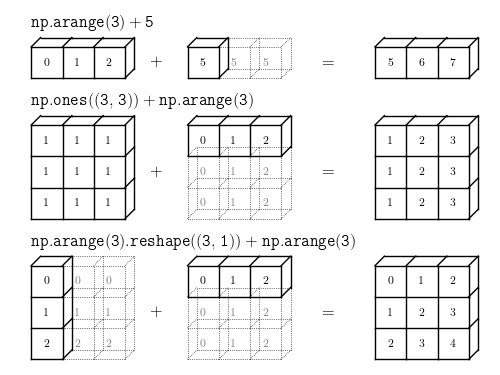

브로드캐스팅은 어떤 조건만 만족한다면 모양이 다른 배열끼리의 연산도 가능하게 해주며 모양이 부족한 부분은 확장하여 연산을 수행할 수 있도록 한다는 것이라고 생각할 수 있다.

1.   **배열과 스칼라를 더한 경우.**
2.   **배열 간의 계산으로 배열의 차원이 확대된 경우**
3.   **브로드캐스팅의 확장성 측면을 극명하게 보여주는 케이스(배열+배열)**


첫번째 그림은 일반적인 파이썬 리스트를 사용하면 for문을 이용해야 같은 결과를 얻을 수 있지만, NumPy에서는 브로드캐스팅의 개념 덕분에 5가 0이외에 1과 2의 원소 부분에도 전파(broadcast)되어 계산되어 간단하게 합 연산을 수행하는 것만으로 같은 결과를 얻을 수 있었다.

세번째 그림은 브로드캐스팅의 확장성 측면을 극명하게 보여주는 케이스이다. 3x1 배열과 1x3 배열의 합을 했는데 두 번째에서는 한쪽의 더 낮은 차원의 배열에서만 아래(**0번 축**)방향으로 broadcast한 것에 반해 양 쪽 배열에서 broadcast한 것을 확인할 수 있다.









In [ ]:
#c * d    # 브로드캐스팅 동작
d * c  # 만약 d * c를 하면 어떤 결과가 만들어질까?

array([[ 60,  66,  72,  78],
       [ 70,  77,  84,  91],
       [ 80,  88,  96, 104],
       [ 90,  99, 108, 117]])

#### ① 계산할 때 원소의 개수 일치
브로드케스팅 기능이 있어서 가능한 경우도 있지만, 벡터와 행렬의 원소의 개수가 일치해야 에러가 발생하지 않고 연산이 가능함.

In [ ]:
a = np.arange(1,7).reshape(2,3)
a

array([[1, 2, 3],
       [4, 5, 6]])

In [ ]:
b = np.arange(1,3)
b

array([1, 2])

In [ ]:
a + b

ValueError: operands could not be broadcast together with shapes (2,3) (2,) 

## (6) 축(axis) 계산이 필요한 이유

축(axis)의 기준은 해당 배열의 차원의 shape의 인덱스라고 생각하면 될듯


*   1차원 행렬:
shape: (N,) 유일함.
*   2차원 행렬:
shape: (A,B) A,B를 각각 0,1 인덱스로 생각 -> axis0이 A방향(행방향=1행,2행....행의 진행방향을 말함.)
*   3차원 행렬:
shape: (A,B,C) 0, 1, 2인덱스로 각각 생각 -> axis0이 A방향(개수(면)방향)





### 1)축에 따른 연산

In [ ]:
a = np.arange(1,5).reshape(2,2)
a

array([[1, 2],
       [3, 4]])

In [ ]:
np.sum(a)

np.int64(10)

In [ ]:
np.sum(a, axis=0)

array([4, 6])

In [ ]:
np.sum(a, axis=1)

array([3, 7])

### 2)3차원 배열에서 축에 따른 연산

In [ ]:
a3 = np.arange(1,9).reshape(2,2,2)
a3

array([[[1, 2],
        [3, 4]],

       [[5, 6],
        [7, 8]]])

In [ ]:
a3[0]

array([[1, 2],
       [3, 4]])

In [ ]:
a3[1]

array([[5, 6],
       [7, 8]])

In [ ]:
np.sum(a3, axis=0)

array([[ 6,  8],
       [10, 12]])

In [ ]:
np.sum(a3, axis=1)

array([[ 4,  6],
       [12, 14]])

In [ ]:
np.sum(a3, axis=2)

array([[ 3,  7],
       [11, 15]])

* 이해 테스트

In [ ]:
a4 = np.arange(3*4*2).reshape(3,4,2)
a4

array([[[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7]],

       [[ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15]],

       [[16, 17],
        [18, 19],
        [20, 21],
        [22, 23]]])

In [ ]:
# 결과 예측해서 적어보고, 실행해서 맞는지 확인해 보자.
np.sum(a4, axis=0)

array([[24, 27],
       [30, 33],
       [36, 39],
       [42, 45]])

In [ ]:
# 결과 예측해서 적어보고, 실행해서 맞는지 확인해 보자.
np.sum(a4, axis=1)

In [ ]:
# 결과 예측해서 적어보고, 실행해서 맞는지 확인해 보자.
np.sum(a4, axis=2)



---



### 3)축 변환 및 이동하기

In [ ]:
t1 = np.arange(3*4*2).reshape(3,4,2)
print(t1.shape)
print(t1)

(3, 4, 2)
[[[ 0  1]
  [ 2  3]
  [ 4  5]
  [ 6  7]]

 [[ 8  9]
  [10 11]
  [12 13]
  [14 15]]

 [[16 17]
  [18 19]
  [20 21]
  [22 23]]]


* transpose() 이용하여 축 변환

In [ ]:
# shape이 (3, 4, 2)인 배열에 대해
# transpose(0, 2, 1) 0번 축은 그대로 두고, 1번과 2번 축을 변경
#, 즉 (3, 2, 4)의 모양으로 변형
t2 = t1.transpose(0, 2, 1)
print(t2.shape)
print(t2)

(3, 2, 4)
[[[ 0  2  4  6]
  [ 1  3  5  7]]

 [[ 8 10 12 14]
  [ 9 11 13 15]]

 [[16 18 20 22]
  [17 19 21 23]]]


In [ ]:
# shape이 (3, 4, 2)인 배열에 대해
# transpose(2, 1, 0) 열은 면으로, 행은 그대로, 면을 열로 축을 변경
#, 즉 (2, 4, 3)의 모양으로 변형
t3 = t1.transpose(2, 1, 0)
print(t3.shape)
print(t3)

(2, 4, 3)
[[[ 0  8 16]
  [ 2 10 18]
  [ 4 12 20]
  [ 6 14 22]]

 [[ 1  9 17]
  [ 3 11 19]
  [ 5 13 21]
  [ 7 15 23]]]


In [ ]:
# shape이 (3, 4, 2)인 배열에 대해
# transpose(1, 2, 0) 행은 면으로, 열은 행으로, 면은 열로 축을 변경
#, 즉 (4, 2, 3)의 모양으로 변형
t4 = t1.transpose(1, 2, 0)
print(t4.shape)
print(t4)

(4, 2, 3)
[[[ 0  8 16]
  [ 1  9 17]]

 [[ 2 10 18]
  [ 3 11 19]]

 [[ 4 12 20]
  [ 5 13 21]]

 [[ 6 14 22]
  [ 7 15 23]]]


* rollaxis(a, axis, start=0)를 이용하여 축 변환
 + a : 배열
 + axis : 옮길 축
 + start : 생략하면 기본값은 0

In [ ]:
ra = np.ones((3,4,5,3))
ra

array([[[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]],


       [[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]],


       [[[1., 1., 1.],
         [1., 1., 1.],
         [1., 

In [ ]:
np.rollaxis(ra, 3).shape

(3, 3, 4, 5)

In [ ]:
np.rollaxis(ra, 3, 1).shape

(3, 3, 4, 5)

In [ ]:
np.rollaxis(ra, 2).shape

(5, 3, 4, 3)

In [ ]:
np.rollaxis(ra, 2, 1).shape

(3, 5, 4, 3)

### 4)잘 이해하고 있는지 테스트해 보자

In [ ]:
import numpy as np
a = [[[ 7,  8],
      [ 5,  6],
      [ 3,  4],
      [ 1,  2]],
     [[10,  9],
      [12, 11],
      [14, 13],
      [16, 15]],
     [[21, 22],
      [20, 19],
      [17, 18],
      [24, 23]]]
arr = np.array(a)
print(arr.shape)
print(arr)

(3, 4, 2)
[[[ 7  8]
  [ 5  6]
  [ 3  4]
  [ 1  2]]

 [[10  9]
  [12 11]
  [14 13]
  [16 15]]

 [[21 22]
  [20 19]
  [17 18]
  [24 23]]]


In [ ]:
# 2번 축(열)을 0번 축(면)에 가져다 놓고 roll
c = np.rollaxis(arr, 2)
print(c.shape)
print(c)

(2, 3, 4)
[[[ 7  5  3  1]
  [10 12 14 16]
  [21 20 17 24]]

 [[ 8  6  4  2]
  [ 9 11 13 15]
  [22 19 18 23]]]


In [ ]:
# 2번 축(열)을 1번 축(행)에 가져다 놓고 roll
d = np.rollaxis(arr, 2, 1)
print(d.shape)
print(d)

(3, 2, 4)
[[[ 7  5  3  1]
  [ 8  6  4  2]]

 [[10 12 14 16]
  [ 9 11 13 15]]

 [[21 20 17 24]
  [22 19 18 23]]]


In [ ]:
# 그렇다면 다음의 결과는 어떻게 될까?
# 1번 축(행)을 0번 축(면)에 가져다 놓고 roll
e =np.rollaxis(arr, 1)
print(e.shape)
print(e)

## (7) 배열 확장 및 축소하기

### 1)수직축이나 수평축만 확장 및 축소하기

* expand_dims() 사용하여 축 확장

In [ ]:
# 2개의 원소 값을 가진 1차원 벡터
x = np.array([1,2])
x.shape

(2,)

In [ ]:
# axis=1 좀 헤깔릴 수 있음
y = np.expand_dims(x, axis=1)
y

array([[1],
       [2]])

In [ ]:
y.shape

(2, 1)

In [ ]:
# axis=0 좀 헤깔릴 수 있음
z = np.expand_dims(x, axis=0)
z

array([[1, 2]])

In [ ]:
z.shape

(1, 2)

In [ ]:
# 비교해 보고 편한 것 써라!
x[:, np.newaxis]

array([[1],
       [2]])

In [ ]:
x[np.newaxis, :]

array([[1, 2]])

### 2)2차원을 1차원으로 축소하기

In [ ]:
x = np.arange(9).reshape(3,3)
x

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

* flatten() : 새로운 배열을 만들어서 1차원 배열 반환

In [ ]:
y = x.flatten()
y[2] = 100
print(y)
print(x)

[  0   1 100   3   4   5   6   7   8]


array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [ ]:
# 메모리 공유?
np.may_share_memory(x, y)

False

* ravel() : 1차원 배열로 변환. 실제 원본 배열 공유

In [ ]:
z = x.ravel()
z[1] = 999
print(z)
print(x)

[[  0 999   2]
 [  3   4   5]
 [  6   7   8]]
[  0 999   2   3   4   5   6   7   8]


In [ ]:
# 메모리 공유?
np.may_share_memory(x, z)

True

## (8) 복사(copy)와 뷰(view) 이해하기


* 배열을 변수에 할당

In [ ]:
a = np.array([[1,2],[3,4]])
a

array([[1, 2],
       [3, 4]])

In [ ]:
# a 배열에 대해 b라는 별칭(alias)을 만든 것.
# 이때는 뷰의 개념과 상관없이 같은 곳을 다른 이름으로 부르는 것임.
b = a
b

array([[1, 2],
       [3, 4]])

In [ ]:
a is b

True

In [ ]:
np.may_share_memory(a, b)

True

In [ ]:
b[0] = 999
b

array([[999, 999],
       [  3,   4]])

In [ ]:
# b를 변경한 후 a를 출력해 보면?
a

array([[999, 999],
       [  3,   4]])

* 뷰(view, 다차원 배열 객체에 대한 메모리 공유 구조)를 사용하는 이유
 + 메모리 절약 및 성능 향상
 + base 속성 활용하여 확인 가능
 + 단, 원본이 변경될 수 있으므로 주의 필요


In [ ]:
f = np.arange(4, 9)
f

array([4, 5, 6, 7, 8])

In [ ]:
e = f.copy()
np.may_share_memory(f, e)

False

In [ ]:
# base 속성이 None이라는 것은 새롭게 만들어진 객체라는 의미
e.base is None

True

In [ ]:
e[1] = 9999
f

array([4, 5, 6, 7, 8])

In [ ]:
g = f[:]
g

array([4, 5, 6, 7, 8])

In [ ]:
# base 속성이 None이 아니라는 것은 공유하는 객체가 있다는 의미
g.base is None

False

In [ ]:
g.base is f

True

In [ ]:
g[1] = 9999
f

array([   4, 9999,    6,    7,    8])

* 뷰의 실제 활용

In [ ]:
#기본 자료 준비
a = np.arange(1,9)
a

array([1, 2, 3, 4, 5, 6, 7, 8])

In [ ]:
a.data.hex()

'01000000000000000200000000000000030000000000000004000000000000000500000000000000060000000000000007000000000000000800000000000000'

In [ ]:
#다양한 형태로 변형하여 활용 가능
b = a.reshape(2,4)
b

array([[1, 2, 3, 4],
       [5, 6, 7, 8]])

In [ ]:
b.data.hex()

'01000000000000000200000000000000030000000000000004000000000000000500000000000000060000000000000007000000000000000800000000000000'

In [ ]:
b.base is a

True

In [ ]:
b * 3
# b1 = b * 3
# b1

array([[ 9, 18, 27, 36],
       [45, 54, 63, 72]])

In [ ]:
a

array([1, 2, 3, 4, 5, 6, 7, 8])

In [ ]:
c = a.reshape(2,2,2)
print(c)
c.base is a

[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]


True

In [ ]:
np.sum(c, axis=0)

array([[ 6,  8],
       [10, 12]])

In [ ]:
#a는 여전히 변함없이 존재.
#즉, 원본 훼손없이 다양하게 변형하여 활용하고자 할 때 공유 개념 사용
a

array([1, 2, 3, 4, 5, 6, 7, 8])